# Experiments: single-step MLP (Retro*)

Compare one-step MLP predictions against the ground-truth first step from `routes_possible_test_hard.pkl`.

**Metrics:**
- **hit@k** — correct reactant set found in top-k
- **precursor availability** — fraction of precursors in `origin_dict` (stock)
- **inference time** — latency of a single MLP call

Run cells top to bottom. Plots are in separate sections at the end.

## 1. Imports and paths

In [ ]:
from __future__ import annotations

import json
import pickle
import sys
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from rdkit import Chem

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "one_step_model").is_dir():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DEFAULT_TEMPLATE = REPO_ROOT / "one_step_model" / "template_rules_1.dat"
DEFAULT_TEST_PKL = REPO_ROOT / "dataset" / "routes_possible_test_hard.pkl"
DEFAULT_OUTPUT = REPO_ROOT / "results" / "experiments_mlp.json"

CHECKPOINTS = {
    "v1": REPO_ROOT / "one_step_model" / "saved_rollout_state_1_2048.ckpt",
    "v2": REPO_ROOT / "one_step_model" / "retro_star_value_ours.ckpt",
    "v3": REPO_ROOT / "one_step_model" / "retro_star_zero_ours.ckpt",
}

V1_INTERNAL_TOPK = 50  # V1 calls MLP with topk=50, then truncates

CHECKPOINT_ORDER = ["v1", "v2", "v3"]
CHECKPOINT_LABELS = {
    "v1": "V1 (Retro* default)",
    "v2": "V2 (value ours)",
    "v3": "V3 (zero ours)",
}
COLORS = {"v1": "#4C72B0", "v2": "#DD8452", "v3": "#55A868"}

print(f"REPO_ROOT: {REPO_ROOT}")

REPO_ROOT: /Users/arqoofficial/Документы/git/Retro-R1


## 2. Plot functions

In [ ]:
def aggregate_metrics(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (ck, topk), grp in df.groupby(["checkpoint", "topk"], sort=False):
        hits = grp["hit"].fillna(False).astype(bool)
        hit_ranks = grp.loc[hits, "hit_rank"].dropna()
        rows.append({
            "checkpoint": ck,
            "topk": int(topk),
            "n_molecules": len(grp),
            "hit_rate": hits.mean(),
            "mean_hit_rank": hit_ranks.mean() if len(hit_ranks) else np.nan,
            "mean_frac_precursors_available": grp["frac_precursors_available"].mean(),
            "mean_frac_reactions_all_available": grp["frac_reactions_all_available"].mean(),
            "mean_inference_s": grp["inference_s"].mean(),
        })
    out = pd.DataFrame(rows)
    ck_order = [c for c in CHECKPOINT_ORDER if c in out["checkpoint"].unique()]
    out["checkpoint"] = pd.Categorical(out["checkpoint"], categories=ck_order, ordered=True)
    return out.sort_values(["checkpoint", "topk"])


def _bar_layout(agg: pd.DataFrame) -> tuple[list, list, np.ndarray, float]:
    checkpoints = list(agg["checkpoint"].cat.categories)
    topks = sorted(agg["topk"].unique())
    x = np.arange(len(topks))
    width = 0.35 if len(checkpoints) == 2 else 0.25
    return checkpoints, topks, x, width


def plot_hit_rate_by_topk(agg: pd.DataFrame) -> None:
    checkpoints, topks, x, width = _bar_layout(agg)
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, ck in enumerate(checkpoints):
        sub = agg[agg["checkpoint"] == ck].set_index("topk")
        vals = [sub.loc[k, "hit_rate"] * 100 if k in sub.index else 0 for k in topks]
        offset = (i - (len(checkpoints) - 1) / 2) * width
        bars = ax.bar(
            x + offset, vals, width,
            label=CHECKPOINT_LABELS.get(ck, ck),
            color=COLORS.get(ck, f"C{i}"),
            edgecolor="white",
        )
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=9,
            )
    ax.set_xticks(x)
    ax.set_xticklabels([f"top-{k}" for k in topks])
    ax.set_ylabel("Hit rate (%)")
    ax.set_xlabel("Top-k predictions")
    ax.set_ylim(0, 105)
    ax.set_title("Ground-truth hit@k (first retrosynthetic step)")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_per_molecule_heatmap(df: pd.DataFrame, topk: int) -> None:
    sub = df[df["topk"] == topk].copy()
    checkpoints = [c for c in CHECKPOINT_ORDER if c in sub["checkpoint"].unique()]
    routes = sorted(sub["route_index"].unique())
    hit_matrix = np.full((len(checkpoints), len(routes)), np.nan)
    rank_matrix = np.full((len(checkpoints), len(routes)), np.nan)

    for i, ck in enumerate(checkpoints):
        for j, route in enumerate(routes):
            row = sub[(sub["checkpoint"] == ck) & (sub["route_index"] == route)]
            if row.empty:
                continue
            r = row.iloc[0]
            hit_matrix[i, j] = 1.0 if r["hit"] else 0.0
            if r["hit"] and pd.notna(r["hit_rank"]):
                rank_matrix[i, j] = float(r["hit_rank"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), gridspec_kw={"width_ratios": [1, 1.2]})
    im0 = axes[0].imshow(hit_matrix, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    axes[0].set_yticks(range(len(checkpoints)))
    axes[0].set_yticklabels([CHECKPOINT_LABELS.get(c, c) for c in checkpoints])
    axes[0].set_xticks(range(len(routes)))
    axes[0].set_xticklabels([f"R{r}" for r in routes], rotation=45, ha="right")
    axes[0].set_title(f"Hit / miss (top-{topk})")
    for i in range(hit_matrix.shape[0]):
        for j in range(hit_matrix.shape[1]):
            if np.isnan(hit_matrix[i, j]):
                continue
            axes[0].text(j, i, "✓" if hit_matrix[i, j] else "✗", ha="center", va="center", fontsize=12)
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="hit")

    masked = np.ma.masked_where(np.isnan(rank_matrix) | (hit_matrix == 0), rank_matrix)
    im1 = axes[1].imshow(masked, aspect="auto", cmap="viridis_r", vmin=0, vmax=max(topk - 1, 1))
    axes[1].set_yticks(range(len(checkpoints)))
    axes[1].set_yticklabels([CHECKPOINT_LABELS.get(c, c) for c in checkpoints])
    axes[1].set_xticks(range(len(routes)))
    axes[1].set_xticklabels([f"R{r}" for r in routes], rotation=45, ha="right")
    axes[1].set_title(f"Hit rank when found (0 = best, top-{topk})")
    for i in range(rank_matrix.shape[0]):
        for j in range(rank_matrix.shape[1]):
            if np.isnan(rank_matrix[i, j]) or hit_matrix[i, j] == 0:
                continue
            axes[1].text(j, i, f"{int(rank_matrix[i, j])}", ha="center", va="center", color="white", fontsize=10)
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="rank")
    fig.suptitle(f"Per-route comparison at top-{topk}", y=1.02)
    fig.tight_layout()
    plt.show()


def plot_stock_metrics(agg: pd.DataFrame) -> None:
    checkpoints, topks, x, width = _bar_layout(agg)
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, ck in enumerate(checkpoints):
        sub = agg[agg["checkpoint"] == ck].set_index("topk")
        vals = [
            sub.loc[k, "mean_frac_precursors_available"] * 100 if k in sub.index else 0
            for k in topks
        ]
        offset = (i - (len(checkpoints) - 1) / 2) * width
        ax.bar(
            x + offset, vals, width,
            label=CHECKPOINT_LABELS.get(ck, ck),
            color=COLORS.get(ck, f"C{i}"),
            alpha=0.85,
            edgecolor="white",
        )
    ax.set_xticks(x)
    ax.set_xticklabels([f"top-{k}" for k in topks])
    ax.set_ylabel("Mean fraction available (%)")
    ax.set_xlabel("Top-k predictions")
    ax.set_title("Precursor availability in top-k (origin_dict stock)")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_hit_rank_distribution(df: pd.DataFrame, topk: int) -> None:
    hits = df[(df["topk"] == topk) & (df["hit"] == True)].copy()  # noqa: E712
    if hits.empty:
        print(f"No hits for top-{topk} — plot skipped.")
        return
    checkpoints = [c for c in CHECKPOINT_ORDER if c in hits["checkpoint"].unique()]
    fig, ax = plt.subplots(figsize=(8, 4))
    bins = np.arange(-0.5, topk + 0.5, 1)
    for ck in checkpoints:
        ranks = hits.loc[hits["checkpoint"] == ck, "hit_rank"].dropna().astype(int)
        if ranks.empty:
            continue
        ax.hist(
            ranks, bins=bins, alpha=0.55,
            label=CHECKPOINT_LABELS.get(ck, ck),
            color=COLORS.get(ck),
            edgecolor="white",
        )
    ax.set_xticks(range(topk))
    ax.set_xlabel("Hit rank (0 = top prediction)")
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of hit ranks (hits only, top-{topk})")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_inference_time(agg: pd.DataFrame) -> None:
    checkpoints = list(agg["checkpoint"].cat.categories)
    topks = sorted(agg["topk"].unique())
    fig, ax = plt.subplots(figsize=(8, 4))
    for ck in checkpoints:
        sub = agg[agg["checkpoint"] == ck].sort_values("topk")
        ax.plot(
            sub["topk"], sub["mean_inference_s"],
            marker="o",
            label=CHECKPOINT_LABELS.get(ck, ck),
            color=COLORS.get(ck),
        )
    ax.set_xlabel("Top-k")
    ax.set_ylabel("Mean inference time (s)")
    ax.set_title("MLP inference latency vs top-k")
    ax.set_xticks(topks)
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

## 3. Experiment helpers

In [3]:
def canonicalize_smiles_clear_map(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles, sanitize=True)
    if mol is None:
        return ""
    for atom in mol.GetAtoms():
        if atom.HasProp("molAtomMapNumber"):
            atom.ClearProp("molAtomMapNumber")
    try:
        return Chem.MolToSmiles(mol, isomericSmiles=True)
    except Exception:
        return ""


def reactants_key(smiles: str) -> tuple[str, ...]:
    parts = []
    for frag in smiles.split("."):
        frag = frag.strip()
        if not frag:
            continue
        canon = canonicalize_smiles_clear_map(frag)
        if canon:
            parts.append(canon)
    return tuple(sorted(parts))


def extract_first_step_ground_truth(route: list[str]) -> tuple[str, str, tuple[str, ...]]:
    if ">>" not in route[0]:
        raise ValueError(f"Invalid route step: {route[0]!r}")
    target, gt_reactants = route[0].split(">>", 1)
    return target.strip(), gt_reactants.strip(), reactants_key(gt_reactants)


def prediction_matches_gt(predicted_reactants: str, gt_key: tuple[str, ...]) -> bool:
    return reactants_key(predicted_reactants) == gt_key


def find_gt_hit(predictions: list[str], gt_key: tuple[str, ...], topk: int) -> dict:
    for rank, pred in enumerate(predictions[:topk]):
        if prediction_matches_gt(pred, gt_key):
            return {"hit": True, "hit_rank": rank, "hit_reactants": pred}
    return {"hit": False, "hit_rank": None, "hit_reactants": None}


def load_starting_mols(path: Path, cache_path: Path | None) -> set[str]:
    if cache_path and cache_path.is_file():
        with cache_path.open("rb") as f:
            return pickle.load(f)
    if not path.is_file():
        raise FileNotFoundError(f"Starting molecules file not found: {path}")
    starting = set(pd.read_csv(path, usecols=["mol"])["mol"])
    if cache_path:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        with cache_path.open("wb") as f:
            pickle.dump(starting, f, protocol=pickle.HIGHEST_PROTOCOL)
    return starting


@dataclass
class TestCase:
    route_index: int
    target_smiles: str
    gt_reactants: str | None
    gt_reactants_key: tuple[str, ...] | None


def load_test_cases(
    test_pkl: Path,
    indices: Iterable[int] | None,
    n_mols: int,
    smiles_list: list[str] | None,
) -> list[TestCase]:
    if smiles_list:
        return [TestCase(i, s, None, None) for i, s in enumerate(smiles_list)]
    with test_pkl.open("rb") as f:
        routes = pickle.load(f)
    idx_list = list(indices) if indices is not None else list(range(min(n_mols, len(routes))))
    cases: list[TestCase] = []
    for i in idx_list:
        target, gt_smi, gt_key = extract_first_step_ground_truth(routes[i])
        cases.append(TestCase(i, target, gt_smi, gt_key))
    return cases


def mark_availability(reactants_smiles: str, starting_mols: set[str]) -> list[dict]:
    return [
        {"smiles": smi, "status": "available" if smi in starting_mols else "unavailable"}
        for smi in reactants_smiles.split(".")
    ]


@dataclass
class ReactionSummary:
    rank: int
    score: float
    score_reference: float
    reactants: str
    matches_ground_truth: bool
    precursors: list[dict]
    n_available: int
    n_unavailable: int
    all_available: bool
    any_available: bool


@dataclass
class MoleculeRun:
    route_index: int
    target_smiles: str
    checkpoint: str
    topk: int
    n_predictions: int
    ground_truth_reactants: str | None
    hit: bool
    hit_rank: int | None
    reactions: list[ReactionSummary]
    frac_precursors_available: float
    frac_reactions_all_available: float


def run_one_molecule(model, case: TestCase, checkpoint_key: str, topk: int, starting_mols: set[str]) -> MoleculeRun | None:
    is_v1 = checkpoint_key == "v1"
    mlp_topk = V1_INTERNAL_TOPK if is_v1 else topk
    results = model.run(case.target_smiles, topk=mlp_topk)
    if not results:
        return None

    reactants_ = results["reactants"]
    scores = results["scores"]
    scores_ref = results.get("scores_reference", scores)
    ranked = sorted(zip(reactants_, scores, scores_ref), key=lambda x: x[1], reverse=True)[:topk]

    gt_key = case.gt_reactants_key
    hit_info = find_gt_hit(reactants_, gt_key, topk) if gt_key is not None else {"hit": False, "hit_rank": None, "hit_reactants": None}

    reactions: list[ReactionSummary] = []
    total_prec = avail_prec = all_avail_reactions = 0

    for rank, (rxn, sc, sc_ref) in enumerate(ranked):
        precursors = mark_availability(rxn, starting_mols)
        n_avail = sum(1 for p in precursors if p["status"] == "available")
        n_unavail = len(precursors) - n_avail
        total_prec += len(precursors)
        avail_prec += n_avail
        all_avail = n_unavail == 0 and len(precursors) > 0
        if all_avail:
            all_avail_reactions += 1
        matches_gt = prediction_matches_gt(rxn, gt_key) if gt_key is not None else False
        reactions.append(
            ReactionSummary(
                rank=rank, score=float(sc), score_reference=float(sc_ref), reactants=rxn,
                matches_ground_truth=matches_gt, precursors=precursors,
                n_available=n_avail, n_unavailable=n_unavail,
                all_available=all_avail, any_available=n_avail > 0,
            )
        )

    frac_prec = (avail_prec / total_prec) if total_prec else 0.0
    frac_rxn_all = all_avail_reactions / len(reactions) if reactions else 0.0

    return MoleculeRun(
        route_index=case.route_index, target_smiles=case.target_smiles, checkpoint=checkpoint_key,
        topk=topk, n_predictions=len(reactions), ground_truth_reactants=case.gt_reactants,
        hit=hit_info["hit"], hit_rank=hit_info["hit_rank"], reactions=reactions,
        frac_precursors_available=frac_prec, frac_reactions_all_available=frac_rxn_all,
    )


def aggregate_hit_rate(rows: list[dict], ck: str, topk: int) -> float | None:
    subset = [r for r in rows if r["checkpoint"] == ck and r["topk"] == topk and r.get("hit") is not None and r["n_predictions"] > 0]
    if not subset:
        return None
    return sum(1 for r in subset if r["hit"]) / len(subset)

## 4. Configuration

Edit parameters here. Set `skip_run=True` to load an existing JSON and skip MLP inference.

In [4]:
CONFIG = {
    "checkpoints": ["v1", "v2"],       # v1, v2, v3
    "topk": [5, 10, 20],
    "num_molecules": 8,
    "indices": None,                     # e.g. [0, 1, 5, 12]
    "smiles": None,                      # explicit SMILES list (no GT)
    "test_pkl": DEFAULT_TEST_PKL,
    "device": -1,                        # -1 = CPU
    "quiet": True,
    "output": DEFAULT_OUTPUT,
    "skip_run": False,                   # True → load JSON, skip MLP
    "heatmap_topk": 10,                  # top-k for heatmap and rank distribution
}

## 5. Run experiment

In [5]:
summary_rows: list[dict] = []
all_runs: list[dict] = []
payload: dict = {}

if CONFIG["skip_run"] and CONFIG["output"].is_file():
    print(f"SKIP_RUN: loading {CONFIG['output']}")
    with CONFIG["output"].open(encoding="utf-8") as f:
        payload = json.load(f)
    summary_rows = payload["summary"]
else:
    canonical = REPO_ROOT / "dataset" / "origin_dict_canonical.csv"
    origin = REPO_ROOT / "dataset" / "origin_dict.csv"
    starting_path = canonical if canonical.is_file() else origin
    cache_path = REPO_ROOT / "dataset" / ".starting_mols_set.pkl"

    print("Loading starting molecules…", flush=True)
    t0 = time.time()
    starting_mols = load_starting_mols(starting_path, cache_path)
    print(f"  {len(starting_mols):,} molecules in {time.time() - t0:.1f}s")

    if not CONFIG["test_pkl"].is_file() and not CONFIG["smiles"]:
        raise FileNotFoundError(f"Test pkl not found: {CONFIG['test_pkl']}")

    cases = load_test_cases(CONFIG["test_pkl"], CONFIG["indices"], CONFIG["num_molecules"], CONFIG["smiles"])
    has_gt = cases[0].gt_reactants_key is not None if cases else False
    print(f"Test molecules: {len(cases)}  (ground-truth: {'yes' if has_gt else 'no'})")

    from mlp_retrosyn.mlp_inference import MLPModel

    if not DEFAULT_TEMPLATE.is_file():
        raise FileNotFoundError(f"Templates not found: {DEFAULT_TEMPLATE}")

    for ck in CONFIG["checkpoints"]:
        ckpt_path = CHECKPOINTS[ck]
        if not ckpt_path.is_file():
            print(f"SKIP {ck}: missing {ckpt_path}")
            continue

        print(f"\nLoading MLP [{ck}]…", flush=True)
        t_load = time.time()
        model = MLPModel(str(ckpt_path), str(DEFAULT_TEMPLATE), device=CONFIG["device"])
        print(f"  loaded in {time.time() - t_load:.1f}s")

        for topk in CONFIG["topk"]:
            for case in cases:
                t_run = time.time()
                run = run_one_molecule(model, case, ck, topk, starting_mols)
                elapsed = time.time() - t_run

                if run is None:
                    summary_rows.append({
                        "route_index": case.route_index, "checkpoint": ck, "topk": topk,
                        "n_predictions": 0, "hit": None, "hit_rank": None,
                        "frac_precursors_available": None, "frac_reactions_all_available": None,
                        "inference_s": elapsed,
                    })
                    continue

                row = {
                    "route_index": run.route_index, "target_smiles": run.target_smiles,
                    "ground_truth_reactants": run.ground_truth_reactants, "checkpoint": ck,
                    "topk": topk, "n_predictions": run.n_predictions,
                    "hit": run.hit if has_gt else None, "hit_rank": run.hit_rank,
                    "frac_precursors_available": run.frac_precursors_available,
                    "frac_reactions_all_available": run.frac_reactions_all_available,
                    "inference_s": round(elapsed, 3),
                }
                summary_rows.append(row)
                all_runs.append({**row, "reactions": [asdict(r) for r in run.reactions]})

                if CONFIG["quiet"]:
                    hit_s = f"hit@{topk} rank={run.hit_rank}" if run.hit else (f"miss@{topk}" if has_gt else "")
                    print(f"  [{ck} k={topk} idx={case.route_index}] avail={run.frac_precursors_available:.0%} {hit_s} {elapsed:.2f}s")

    payload = {
        "config": {
            "checkpoints": CONFIG["checkpoints"], "topk": CONFIG["topk"],
            "starting_mols": str(starting_path), "test_pkl": str(CONFIG["test_pkl"]),
            "device": CONFIG["device"],
            "ground_truth_matching": "canonical isomeric SMILES, sorted fragments",
        },
        "summary": summary_rows,
        "aggregate_hit_rate": {
            f"{ck}_topk_{k}": aggregate_hit_rate(summary_rows, ck, k)
            for ck in CONFIG["checkpoints"] for k in CONFIG["topk"]
        },
        "runs": all_runs,
    }
    CONFIG["output"].parent.mkdir(parents=True, exist_ok=True)
    with CONFIG["output"].open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)
    print(f"\nWrote {CONFIG['output']}")

df = pd.DataFrame(payload["summary"])
df = df[df["n_predictions"] > 0].copy()
display(df)

Loading starting molecules…
  23,081,629 molecules in 5.6s
Test molecules: 8  (ground-truth: yes)

Loading MLP [v1]…
USE PDVN MLP


template rules: 381302it [00:00, 1342480.07it/s]
template rules: 381302it [00:00, 1166168.64it/s]


  loaded in 3.5s
  [v1 k=5 idx=0] avail=29% hit@5 rank=1 0.67s
  [v1 k=5 idx=1] avail=17% hit@5 rank=0 3.64s
  [v1 k=5 idx=2] avail=29% hit@5 rank=2 0.65s
  [v1 k=5 idx=3] avail=25% hit@5 rank=0 0.28s
  [v1 k=5 idx=4] avail=17% hit@5 rank=0 0.35s
  [v1 k=5 idx=5] avail=29% hit@5 rank=3 0.47s
  [v1 k=5 idx=6] avail=40% hit@5 rank=0 0.65s
  [v1 k=5 idx=7] avail=29% miss@5 0.55s
  [v1 k=10 idx=0] avail=33% hit@10 rank=1 0.47s
  [v1 k=10 idx=1] avail=29% hit@10 rank=0 0.28s
  [v1 k=10 idx=2] avail=29% hit@10 rank=2 0.27s
  [v1 k=10 idx=3] avail=31% hit@10 rank=0 0.28s
  [v1 k=10 idx=4] avail=10% hit@10 rank=0 0.37s
  [v1 k=10 idx=5] avail=23% hit@10 rank=3 0.40s
  [v1 k=10 idx=6] avail=30% hit@10 rank=0 0.43s
  [v1 k=10 idx=7] avail=17% miss@10 0.46s
  [v1 k=20 idx=0] avail=33% hit@20 rank=1 0.34s
  [v1 k=20 idx=1] avail=25% hit@20 rank=0 0.34s
  [v1 k=20 idx=2] avail=29% hit@20 rank=2 0.27s
  [v1 k=20 idx=3] avail=29% hit@20 rank=0 0.28s
  [v1 k=20 idx=4] avail=10% hit@20 rank=0 0.46s
  [

template rules: 381302it [00:00, 731367.42it/s]
template rules: 381302it [00:00, 1241266.76it/s]


  loaded in 3.8s
  [v2 k=5 idx=0] avail=29% hit@5 rank=1 2.15s
  [v2 k=5 idx=1] avail=17% hit@5 rank=1 0.29s
  [v2 k=5 idx=2] avail=29% hit@5 rank=2 0.25s
  [v2 k=5 idx=3] avail=25% hit@5 rank=0 0.28s
  [v2 k=5 idx=4] avail=17% hit@5 rank=0 0.37s
  [v2 k=5 idx=5] avail=29% hit@5 rank=3 0.41s
  [v2 k=5 idx=6] avail=40% hit@5 rank=0 0.42s
  [v2 k=5 idx=7] avail=17% miss@5 0.46s
  [v2 k=10 idx=0] avail=33% hit@10 rank=1 0.33s
  [v2 k=10 idx=1] avail=29% hit@10 rank=1 0.28s
  [v2 k=10 idx=2] avail=29% hit@10 rank=2 0.40s
  [v2 k=10 idx=3] avail=31% hit@10 rank=0 0.31s
  [v2 k=10 idx=4] avail=10% hit@10 rank=0 0.37s
  [v2 k=10 idx=5] avail=23% hit@10 rank=4 0.42s
  [v2 k=10 idx=6] avail=35% hit@10 rank=0 0.43s
  [v2 k=10 idx=7] avail=17% miss@10 0.46s
  [v2 k=20 idx=0] avail=33% hit@20 rank=1 0.33s
  [v2 k=20 idx=1] avail=25% hit@20 rank=1 0.24s
  [v2 k=20 idx=2] avail=29% hit@20 rank=2 0.26s
  [v2 k=20 idx=3] avail=29% hit@20 rank=0 0.30s
  [v2 k=20 idx=4] avail=10% hit@20 rank=0 0.48s
  [

,route_index,target_smiles,ground_truth_reactants,checkpoint,topk,n_predictions,hit,hit_rank,frac_precursors_available,frac_reactions_all_available,inference_s
0,0,C[C@H](c1ccccc1)N1C[C@]2(C(=O)OC(C)(C)C)C=CC[C...,C[C@H](c1ccccc1)N1C[C@]2(C(=O)OC(C)(C)C)C=CC[C...,v1,5,5,True,1.0,0.285714,0.0,0.673
1,1,CCCC[C@@H](C(=O)N1CCC[C@H]1C(=O)O)[C@@H](F)C(=...,CCCC[C@@H](C(=O)N1CCC[C@H]1C(=O)OC(C)(C)C)[C@@...,v1,5,5,True,0.0,0.166667,0.0,3.640
2,2,CC(C)c1ccc(-n2nc(O)c3c(=O)c4ccc(Cl)cc4[nH]c3c2...,CC(C)c1ccc(NN)cc1.COC(=O)c1nc2cc(Cl)ccc2c(O)c1...,v1,5,5,True,2.0,0.285714,0.0,0.650
3,3,CCOC(=O)c1nc(N2CC[C@H](NC(=O)c3nc(C(F)(F)F)c(C...,CCOC(=O)c1nc(N2CC[C@H](N)[C@H](OC)C2)sc1C.CCc1...,v1,5,5,True,0.0,0.250000,0.0,0.281
4,4,NC1=N[C@@]2(c3ccc(F)cc3F)CO[C@@H](c3nnco3)C[C@...,O=C(NC1=N[C@@]2(c3ccc(F)cc3F)CO[C@@H](c3nnco3)...,v1,5,5,True,0.0,0.166667,0.0,0.355
5,5,COc1ccc2c(Nc3c(Cl)cncc3Cl)cc(=O)[nH]c2c1OCCCCC...,COc1ccc2c(Nc3c(Cl)cncc3Cl)cc(=O)[nH]c2c1OCCCCC...,v1,5,5,True,3.0,0.285714,0.0,0.474
6,6,COCCCc1cc(CN(C(=O)[C@H]2CN(C(=O)OC(C)(C)C)CC[C...,COCCCc1cc(O)cc(CN(C(=O)[C@H]2CN(C(=O)OC(C)(C)C...,v1,5,5,True,0.0,0.400000,0.0,0.646
7,7,O=C(OCc1ccccc1)N1CC[C@H]2CCCN(CCc3ccccc3)C[C@H]21,c1ccc(CCN2CCC[C@@H]3CCN[C@@H]3C2)cc1.O=C(Cl)OC...,v1,5,5,False,NaN,0.285714,0.0,0.547
8,0,C[C@H](c1ccccc1)N1C[C@]2(C(=O)OC(C)(C)C)C=CC[C...,C[C@H](c1ccccc1)N1C[C@]2(C(=O)OC(C)(C)C)C=CC[C...,v1,10,6,True,1.0,0.333333,0.0,0.469
9,1,CCCC[C@@H](C(=O)N1CCC[C@H]1C(=O)O)[C@@H](F)C(=...,CCCC[C@@H](C(=O)N1CCC[C@H]1C(=O)OC(C)(C)C)[C@@...,v1,10,10,True,0.0,0.285714,0.0,0.277


## 6. Aggregated metrics

In [6]:
agg = aggregate_metrics(df)
display(agg)
print("\nNote: small sample size — V1 vs V2 differences are not statistically significant.")

,checkpoint,topk,n_molecules,hit_rate,mean_hit_rank,mean_frac_precursors_available,mean_frac_reactions_all_available,mean_inference_s
0,v1,5,8,0.875,0.857143,0.265774,0.0,0.908250
1,v1,10,8,0.875,0.857143,0.251837,0.0,0.369000
2,v1,20,8,0.875,0.857143,0.253364,0.0,0.427375
3,v2,5,8,0.875,1.000000,0.250893,0.0,0.579375
4,v2,10,8,0.875,1.142857,0.258087,0.0,0.374875
5,v2,20,8,0.875,1.142857,0.253364,0.0,0.364250



Note: small sample size — V1 vs V2 differences are not statistically significant.


---
# Visualizations

Each plot is a separate cell — re-run only the sections you need.

**Quick mode:** set `skip_run=True` in CONFIG and re-run the experiment cell to plot from `results/experiments_mlp.json`.

### Plot 1 — Hit rate by top-k

**What it shows:** fraction of molecules where the correct first retrosynthetic step (ground truth) appears in the top-k MLP predictions.

**How to read:**
- X-axis — top-k size (5, 10, 20), same as agent `tool.topk`.
- Colored bars — checkpoints V1/V2/V3.
- Hit rate should increase with k: more candidates → higher chance of finding GT.
- V1 internally requests top-50 then truncates; V2 uses exactly k.

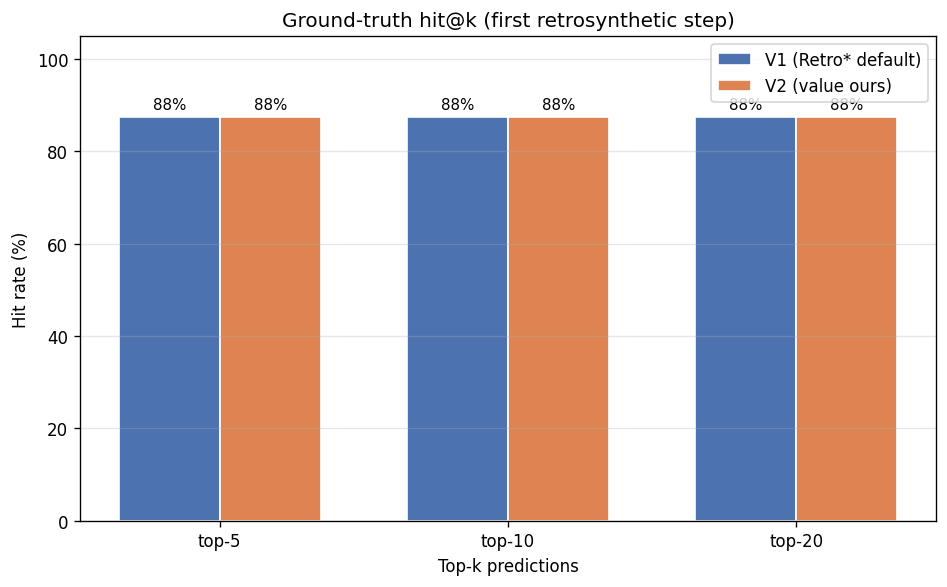

In [7]:
plot_hit_rate_by_topk(agg)

### Plot 2 — Per-route hit/miss heatmap

**What it shows:** detailed checkpoint × route matrix for a chosen top-k.

**How to read:**
- Left panel: ✓/✗ — whether GT is in top-k for each (checkpoint, route) pair.
- Right panel: hit rank (0 = best prediction), hits only.
- Green = hit, red = miss. Useful to spot molecules where the model consistently fails.
- Default `heatmap_topk=10` — change in CONFIG if needed.

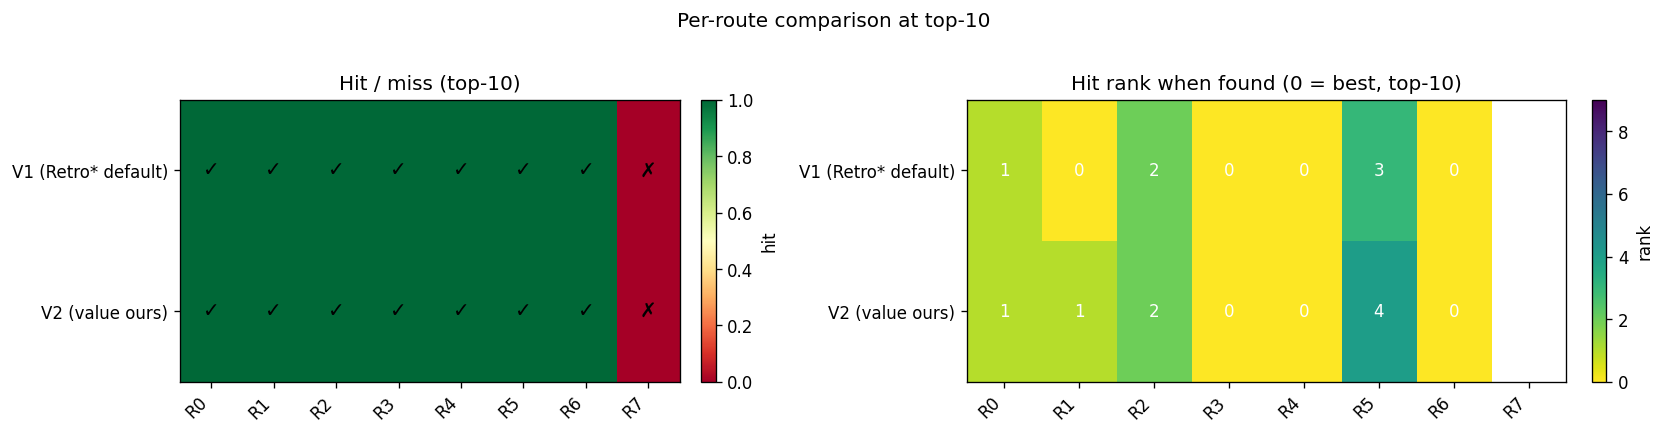

In [8]:
plot_per_molecule_heatmap(df, CONFIG["heatmap_topk"])

### Plot 3 — Precursor availability (stock)

**What it shows:** mean fraction of precursors in top-k predictions that exist in `origin_dict.csv` (commercially available / in stock).

**How to read:**
- High percentage ≠ good synthesis: the model may suggest cheap reagents but not the GT step.
- If `rxns_all_avail ≈ 0%`, no reaction in top-k has all precursors in stock — typical for hard routes.
- Compare checkpoints: one may more often suggest available fragments.

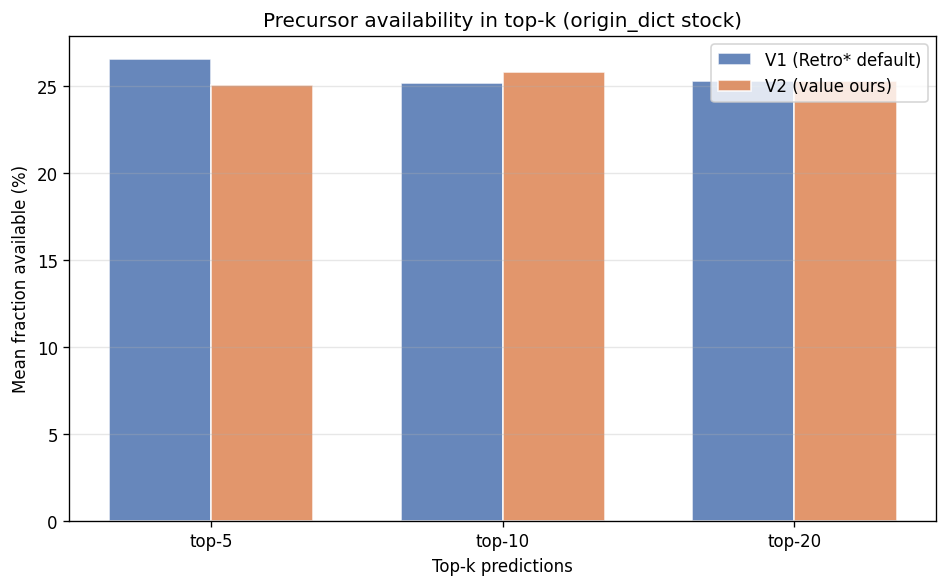

In [9]:
plot_stock_metrics(agg)

### Plot 4 — Hit rank distribution

**What it shows:** histogram of GT ranks among successful hits (cases where GT was found in top-k).

**How to read:**
- Rank 0 — GT is the top prediction (best case).
- Left-skewed distribution — model ranks the correct step higher with more confidence.
- Wide distribution — GT is often deep in the list even when it is a hit.
- Compare V1 vs V2: at the same hit@k, one may produce higher ranks.

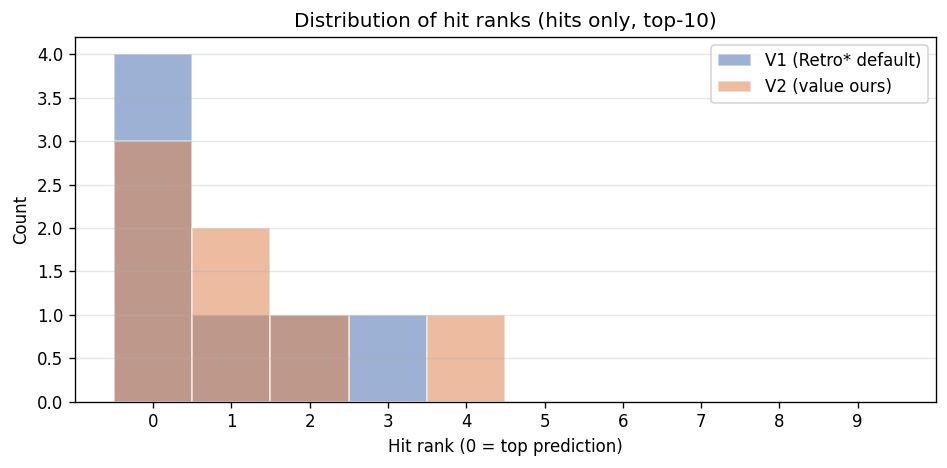

In [10]:
plot_hit_rank_distribution(df, CONFIG["heatmap_topk"])

### Plot 5 — Inference time vs top-k

**What it shows:** mean MLP call latency as a function of top-k.

**How to read:**
- On CPU (Mac), time usually grows with k as more templates/candidates are processed.
- V1 always requests internal top-50 → V1 curve may be flatter at small k.
- Useful for the hit@k vs latency trade-off in the agent.

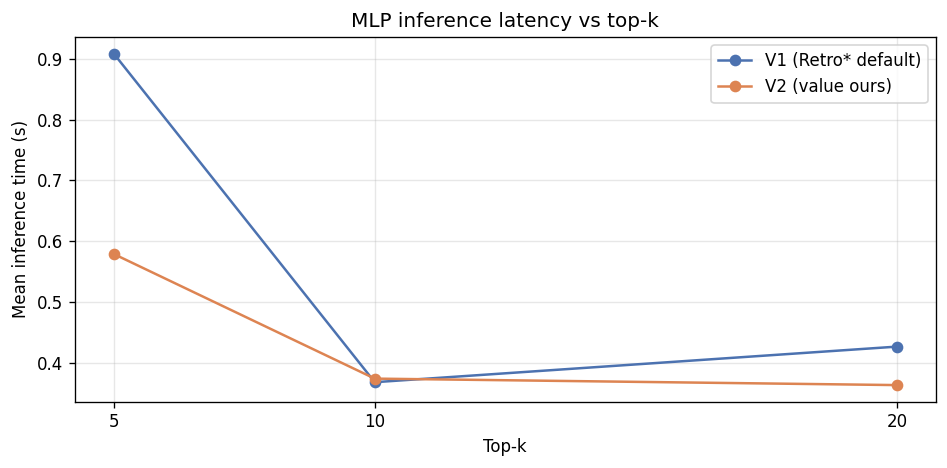

In [11]:
plot_inference_time(agg)

### (Optional) Export aggregated metrics to CSV

In [ ]:
out_dir = REPO_ROOT / "results" / "experiments_plots"
out_dir.mkdir(parents=True, exist_ok=True)
agg.to_csv(out_dir / "aggregated_metrics.csv", index=False)
print(f"CSV: {out_dir / 'aggregated_metrics.csv'}")
print("For PNG export run: uv run python scripts/visualize_experiments_mlp.py")